In [1]:
%pip install -qU pypdf langchain-community langchain-text-splitters

Note: you may need to restart the kernel to use updated packages.


In [2]:
from langchain_community.document_loaders import PyPDFLoader

pdf_file_path = "./income_tax.pdf"

loader = PyPDFLoader(file_path=pdf_file_path)
pages = []

async for page in loader.alazy_load():
    pages.append(page)

c:\Users\JJH\anaconda3\envs\langchain\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
pages[35]

Document(metadata={'producer': 'iText 2.1.7 by 1T3XT', 'creator': 'PyPDF', 'creationdate': '2026-04-21T20:49:56+09:00', 'moddate': '2026-04-21T20:49:56+09:00', 'source': './income_tax.pdf', 'total_pages': 137, 'page': 35, 'page_label': '36'}, page_content='법제처                                                            36                                                       국가법령정보센터\n소득세법\n② 다음 각 호의 어느 하나에 해당하는 경우에는 제1항에 따른 공제[이하 “기장세액공제”(記帳稅額控除)라 한다]를\n적용하지 아니한다.\n1. 비치ㆍ기록한 장부에 의하여 신고하여야 할 소득금액의 100분의 20 이상을 누락하여 신고한 경우\n2. 기장세액공제와 관련된 장부 및 증명서류를 해당 과세표준확정신고기간 종료일부터 5년간 보관하지 아니한 경\n우. 다만, 천재지변 등 대통령령으로 정하는 부득이한 사유에 해당하는 경우에는 그러하지 아니하다.\n③ 기장세액공제에 관하여 필요한 사항은 대통령령으로 정한다.\n[전문개정 2009. 12. 31.]\n \n제56조의3(전자계산서 발급 전송에 대한 세액공제) ① 총수입금액 등을 고려하여 대통령령으로 정하는 사업자가 제\n163조제1항 후단에 따른 전자계산서를 2027년 12월 31일까지 발급(제163조제8항에 따라 전자계산서 발급명세를\n국세청장에게 전송하는 경우로 한정한다)하는 경우에는 전자계산서 발급 건수 등을 고려하여 대통령령으로 정하는\n금액을 해당 과세기간의 사업소득에 대한 종합소득산출세액에서 공제할 수 있다. 이 경우 공제한도는 연간 100만원\n으로 한다. <개정 2021. 12. 8., 2024. 12. 31.

In [4]:
%pip install -q py-zerox # zerox 라이브러리 파싱용

Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


In [5]:
from dotenv import load_dotenv
load_dotenv()

True

In [6]:
%pip install -q nest_asyncio

Note: you may need to restart the kernel to use updated packages.


In [7]:
import nest_asyncio
nest_asyncio.apply()

In [ ]:
from pyzerox import zerox
import os
import json
import asyncio

### Model Setup (Use only Vision Models) Refer: https://docs.litellm.ai/docs/providers ###

## placeholder for additional model kwargs which might be required for some models
kwargs = {}

## system prompt to use for the vision model
custom_system_prompt = None

# to override
# custom_system_prompt = "For the below PDF page, do something..something..." ## example

###################### Example for OpenAI ######################
model = "gpt-4o-mini" ## openai model
os.environ["OPENAI_API_KEY"] ## your-api-key


# Define main async entrypoint
async def main():
    file_path = "./income_tax.pdf" ## local filepath and file URL supported

    ## process only some pages or all
    select_pages = None ## None for all, but could be int or list(int) page numbers (1 indexed)

    output_dir = "./document" ## directory to save the consolidated markdown file
    result = await zerox(file_path=file_path, model=model, output_dir=output_dir,
                        custom_system_prompt=custom_system_prompt,select_pages=select_pages, **kwargs)
    return result


# run the main function:
result = asyncio.run(main())

# print markdown result
print(result)

In [8]:
%pip install -q "unstructured[md]" nltk

Note: you may need to restart the kernel to use updated packages.


In [11]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1500,
    chunk_overlap = 100,
    separators=['\n\n', '\n']
)

In [13]:
from langchain_community.document_loaders import UnstructuredMarkdownLoader
from langchain_core.documents import Document

markdown_path = "./documents/income_tax.md"
loader = UnstructuredMarkdownLoader(markdown_path)
document_list = loader.load_and_split(text_splitter)

In [14]:
document_list[43]

Document(metadata={'source': './documents/income_tax.md'}, page_content='간접투자자에게 지급자에 해당하여 제6조제1항 및 제57조제1항 제1호에 따른 국외법인에 해당하는 개인으로서 간접투자사업이 발생하는 것을 제외하는 구조로 투자적으로 보낼 것 다른 자본사업으로 납부할 것은 규정의 범위에 따라 외국법인에서의 경우 해당 세액을 포함하며, 이하 제1항에서 ‘간접투자외국세액’이라 한다.\n\n제1항을 적용할 때 거주자가 간접투자회사를 통해 지급받은 소득과 종합소득세법에 의해 공제되는 금액은 다음과 같이 한다.\n\n간접투자회사로부터 지급받은 소득: ‘자본시장과 금융투자업에 관한 법률’ 제23조제6항에 따른 기초자산(간접투자와의별임이나 대체가격)을 말하며, 이하 이 조 및 제29조제1항에서 “세액기준가격”이라 한다)기준으로 계산된 금액. 단, 증권시장에서 상장된 간접투자회사의 중립에 따라 간접투자회사의 지급받은 소득은 대통형별로 판단하여 계산한 금액으로 한다.\n\n종합소득산출세액에서 공제하는 금액: 간접투자국법인에서 세후기준가격을 고려하여 대통형별로 정하는 범위에 따라 계산한 금액\n\n제3항에 따라 종합소득산출세액에서 공제할 수 있는 금액은 다음 금액과 이하 함을 “공제한도금액”이라 한다. 이 경우 제1항제2호의 금액에 해당 하는 금액은 다음 과세기간은 개시일부터 10년 이내에 거쳐있는 과세기간으로 이힐여 그의 이월된 과세기간의 공제한도금액 내에 공제할 수 있다.\n\n공제한도금액 = A\n\n      B\n\nA: 제65조에 따라 계산한 당해 과세기간의 종합소득산출세액 B: 간접투자회사로부터 지급받은 소득(상기금액에 대해 간접투자국법인)\n\n제1항부터 제3항까지의 규정에 따른 간접투자회사 등으로부터 지급받은 소득의 계산방법, 그 밖에 세액공제에 필요한 사항은 대통령령으로 정한다. [본조신설 2022. 1. 31.] [시행일: 2022. 1. 1.] 제57조의2\n\n제58조(자산손실세액의귀증) 1. 사

In [15]:
%pip install -q markdown html2text beautifulsoup4

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import markdown
from bs4 import BeautifulSoup

text_path = './documents/income_tax.txt'

# 마크다운 파일을 읽어옵니다
with open(markdown_path, 'r', encoding='utf-8') as md_file:
    md_content = md_file.read()

# 마크다운 콘텐츠를 HTML로 변환합니다
html_content = markdown.markdown(md_content)

# HTML 콘텐츠를 파싱하여 텍스트만 추출합니다
soup = BeautifulSoup(html_content, 'html.parser')
text_content = soup.get_text()

# 추출한 텍스트를 텍스트 파일로 저장합니다
with open(text_path, 'w', encoding='utf-8') as txt_file:
    txt_file.write(text_content)

print("Markdown converted to plain text successfully!")

In [ ]:
from langchain_community.document_loaders import TextLoader

loader = TextLoader(text_path)
document_list = loader.load_and_split(text_splitter)

In [ ]:
document_list[39]

In [16]:
%pip install -q langchain-chroma

Note: you may need to restart the kernel to use updated packages.


In [17]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model='text-embedding-3-large')

In [18]:
from langchain_chroma import Chroma

vector_store = Chroma.from_documents(
    documents=document_list,
    embedding=embeddings,
    collection_name = 'income_tax_collection',
    persist_directory = './income_tax_collection'
)

In [19]:
retriever = vector_store.as_retriever(search_kwargs={'k': 3})

In [20]:
query = '연봉 5천만원 직장인의 소득세는?'

In [21]:
retriever.invoke(query)

[Document(id='7a893f59-b8ce-4a2b-9947-a600879665cb', metadata={'source': './documents/income_tax.md'}, page_content='다. 제16조제1항제10호에 따른 직장공제회초과받환급에 대해서는 기본세율 라. 그 밖의 이자소득에 대해서는 100분의 14\n\n배당소득에 대해서는 다음과 같이 추정하는 세율 가. 제7조제1항제2호에 따른 출자공동사업자의 배당소득에 대해서는 100분의 25 나. 그 밖의 배당소득에 대해서는 100분의 14\n\n원천소득당 사업소득에 대해서는 100분의 3. 단, 외국인 직업운동가가 한국표준산업분류에 따른 스포츠 클래지 사용 명 중 프로스포츠단만의 계약(계약기간이 3년 이하인 경우)을 한다는 조건에 따라 용역을 제공하고 받는 소득에 대해서는 100분의 20으로 한다.\n\n근로소득에 대해서는 기본세율. 단, 임금근로자의 근로소득에 대해서는 100분의 6으로 한다.\n\n공적연금소득에 대해서는 기본세율\n\n59.제210조제3조제1항제2호관련 및 다목에 따른 연금계좌 납입액에 따른 증감지급 금액을 연금수령할 연금소득세에 대해서는 다음 각 호의 구분에 따른 세율. 이 경우 각 목의 요건을 동시에 충족하는 때에는 낮은 세율을 적용한다.\n\n가. 연금소득자와 나이에 따른 단일의 세율 나이(연금수령형태) 세율 70세 미만 100분의 5 70세 이상 100분의 3\n\n스텍스트판'),
 Document(id='ea6177bb-5a20-4d60-9951-c7a878fecec7', metadata={'source': './documents/income_tax.md'}, page_content='10년 초과 20년 이하: 400만원 + 80만원 × (납입연수 - 10년)\n\n20년 초과: 1,200만원 + 120만원 × (납입연수 - 20년)\n\n② 직장근로자 초과관세환급금을 분배하여 지급받는 경우 세액의 계산 방법 등 필요한 사항은 대통령령으로 정한다. <대통령 2

In [22]:
from typing_extensions import List, TypedDict
from langchain_core.documents import Document

class AgentState(TypedDict):
    query: str
    context: List[Document]
    answer: str

In [23]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(AgentState)

In [24]:
def retrieve(state: AgentState) -> AgentState:
    """
    사용자의 질문에 기반하여 벡터 스토어에서 관련 문서를 검색합니다.

    Args:
        state (AgentState): 사용자의 질문을 포함한 에이전트의 현재 state.

    Returns:
        AgentState: 검색된 문서가 추가된 state를 반환합니다.
    """
    query = state['query']  # state에서 사용자의 질문을 추출합니다.
    docs = retriever.invoke(query)  # 질문과 관련된 문서를 검색합니다.
    return {'context': docs}  # 검색된 문서를 포함한 state를 반환합니다.

In [27]:
from langchain_classic import hub
from langchain_openai import ChatOpenAI
prompt = hub.pull("rlm/rag-prompt")
llm = ChatOpenAI(model='gpt-4o')

In [28]:
def generate(state: AgentState) -> AgentState:
    """
    사용자의 질문과 검색된 문서를 기반으로 응답을 생성합니다.

    Args:
        state (AgentState): 사용자의 질문과 검색된 문서를 포함한 에이전트의 현재 state.

    Returns:
        AgentState: 생성된 응답이 추가된 state를 반환합니다.
    """
    context = state['context']  # state에서 검색된 문서를 추출합니다.
    query = state['query']  # state에서 사용자의 질문을 추출합니다.
    rag_chain = prompt | llm  # RAG 프롬프트와 LLM을 연결하여 체인을 만듭니다.
    response = rag_chain.invoke({'question': query, 'context': context})  # 질문과 문맥을 사용하여 응답을 생성합니다.
    return {'answer': response}  # 생성된 응답을 포함한 state를 반환합니다.

In [29]:
graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)

In [30]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'retrieve')
graph_builder.add_edge('retrieve', 'generate')
graph_builder.add_edge('generate', END)

In [31]:
graph = graph_builder.compile()

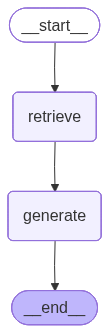

In [32]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [33]:
sequence_graph_builder = StateGraph(AgentState).add_sequence([retrieve, generate])

In [34]:
sequence_graph_builder.add_edge(START, 'retrieve')
sequence_graph_builder.add_edge('generate', END)

In [35]:
sequence_graph = sequence_graph_builder.compile()

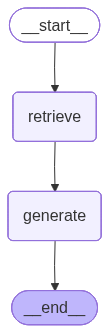

In [36]:
display(Image(sequence_graph.get_graph().draw_mermaid_png()))

In [37]:
initial_state = {'query': query}
graph.invoke(initial_state)

{'query': '연봉 5천만원 직장인의 소득세는?',
 'context': [Document(id='7a893f59-b8ce-4a2b-9947-a600879665cb', metadata={'source': './documents/income_tax.md'}, page_content='다. 제16조제1항제10호에 따른 직장공제회초과받환급에 대해서는 기본세율 라. 그 밖의 이자소득에 대해서는 100분의 14\n\n배당소득에 대해서는 다음과 같이 추정하는 세율 가. 제7조제1항제2호에 따른 출자공동사업자의 배당소득에 대해서는 100분의 25 나. 그 밖의 배당소득에 대해서는 100분의 14\n\n원천소득당 사업소득에 대해서는 100분의 3. 단, 외국인 직업운동가가 한국표준산업분류에 따른 스포츠 클래지 사용 명 중 프로스포츠단만의 계약(계약기간이 3년 이하인 경우)을 한다는 조건에 따라 용역을 제공하고 받는 소득에 대해서는 100분의 20으로 한다.\n\n근로소득에 대해서는 기본세율. 단, 임금근로자의 근로소득에 대해서는 100분의 6으로 한다.\n\n공적연금소득에 대해서는 기본세율\n\n59.제210조제3조제1항제2호관련 및 다목에 따른 연금계좌 납입액에 따른 증감지급 금액을 연금수령할 연금소득세에 대해서는 다음 각 호의 구분에 따른 세율. 이 경우 각 목의 요건을 동시에 충족하는 때에는 낮은 세율을 적용한다.\n\n가. 연금소득자와 나이에 따른 단일의 세율 나이(연금수령형태) 세율 70세 미만 100분의 5 70세 이상 100분의 3\n\n스텍스트판'),
  Document(id='ea6177bb-5a20-4d60-9951-c7a878fecec7', metadata={'source': './documents/income_tax.md'}, page_content='10년 초과 20년 이하: 400만원 + 80만원 × (납입연수 - 10년)\n\n20년 초과: 1,200만원 + 120만원 × (납입연수 - 20년)\n\n② 직장근로자 초과관세환급금을 분배하여 지